# ORT: Kosmologie

**Hoofdstuk 12, deel 3 | §12.22–12.25 | Formules 66–81**

Dit notebook behandelt de kosmologische implicaties van de ORT:
de kosmologische schil, het zwart-gat-binnenste, het heelal-als-BH
hypothese, en donkere materie/energie als randeffecten.

> **Let op**: de secties in dit notebook zijn **speculatief** — ze volgen
> uit het ORT-framework maar zijn niet experimenteel bevestigd.

---

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import *
from ort_plots import (cosmological_shell_diagram, gw_strain_plot, gw_inspiral_interactive,
    kerr_geometry_plot, kerr_frame_drag_field, isco_comparison_plot)
import matplotlib.pyplot as plt
import math
import numpy as np
%matplotlib inline

---
## 1. De kosmologische schil als wit gat (\S 12.22)

De ORT beschrijft zwaartekracht via $c_{\text{local}}(r) = c\sqrt{1 - r_s/r}$.
Wat als we hetzelfde principe toepassen op kosmologische schalen?

### De Hubble-straal

**Formule (66)** -- Hubble-straal:
$$R_H = \frac{c}{H_0} \tag{66}$$

**Formule (67)** -- Hubble's wet:
$$v_{\text{rec}} = H_0 \cdot d \tag{67}$$

Bij $d = R_H$ bereikt de recessiesnelheid exact $c$.

### SpaceTime-interpretatie van de Hubble-rand

**Formule (68)** -- tijdstilstand op de Hubble-rand:
$$v_{\text{tijd}}(d) = c \cdot \sqrt{1 - \frac{d^2}{R_H^2}} \tag{68}$$

Bij $d = R_H$: $v_{\text{ruimte}} = c \Rightarrow v_{\text{tijd}} = 0$ -- **de tijd staat stil op de Hubble-rand**, precies zoals op een eventhorizon.

### De "coincidentie": $r_s \approx R_H$

**Formule (69)** -- Schwarzschild-straal van het heelal:
$$r_s = \frac{2GM_{\text{obs}}}{c^2} \tag{69}$$

**Formule (70)** -- de kosmologische verhouding:
$$\frac{r_s}{R_H} \approx 1.0 \tag{70}$$

### Kritieke dichtheid: $r_s = R_H$ exact

**Formule (71)** -- kritieke dichtheid:
$$\rho_{\text{crit}} = \frac{3H_0^2}{8\pi G} \tag{71}$$

**Bewijs (71b):** De massa in een bol met straal $R_H$ en dichtheid $\rho_{\text{crit}}$:

$$M = \rho_{\text{crit}} \times \tfrac{4}{3}\pi R_H^3 = \frac{c^3}{2GH_0}$$

$$r_s = \frac{2GM}{c^2} = \frac{c}{H_0} = R_H \tag{71b}$$

### Wit-gat interpretatie

| Eigenschap | Zwart gat (buiten) | Kosmologische rand ($R_H$) |
|------------|-------------------|---------------------------|
| $c_{\text{local}}$ | $c\sqrt{1 - r_s/r} \to 0$ | $c\sqrt{1 - d^2/R_H^2} \to 0$ |
| $v_{\text{tijd}}$ | $\to 0$ aan horizon | $\to 0$ aan $R_H$ |
| Signalen | Kunnen er niet uit | Kunnen er niet in |
| Licht | Roodverschoven tot $\infty$ | Roodverschoven tot $\infty$ |

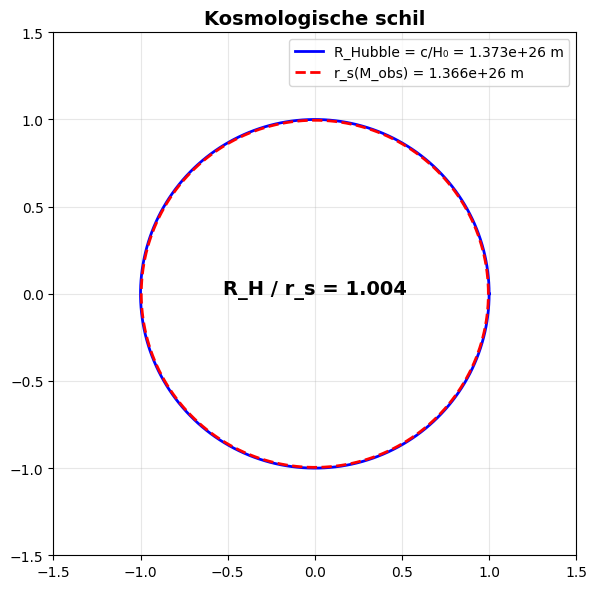

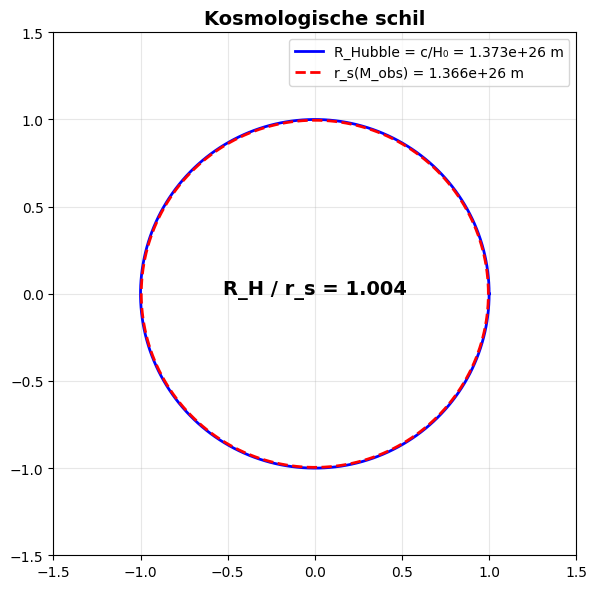

In [2]:
# Kosmologische schil diagram
cosmological_shell_diagram(lang='nl')

In [3]:
# Numerieke berekeningen: kosmologische schil
cosmo = CosmologicalModel()

print("=== Kosmologische Schil (S 12.22) ===")
print(f"\nHubble-straal R_H = c/H0 = {R_HUBBLE:.4e} m")
print(f"Hubble-straal R_H = {R_HUBBLE / (PARSEC * 1e6):.1f} Mpc")
print(f"Hubble-straal R_H = {R_HUBBLE / (9.461e15 * 1e9):.1f} Glj")

print(f"\nSchwarzschild-straal van M_obs:")
print(f"  M_obs = {M_OBSERVABLE:.3e} kg")
print(f"  r_s   = {cosmo.r_s_observable:.4e} m")

ratio = cosmo.ratio_hubble_schwarzschild()
print(f"\nVerhouding R_H / r_s = {ratio:.4f}")
print(f"  --> {'Vrijwel gelijk!' if abs(ratio - 1) < 0.1 else 'Significant verschil'}")

# Kritieke massa
M_crit = CosmologicalModel.schwarzschild_equals_hubble()
print(f"\nKritieke massa (r_s = R_H): M_crit = {M_crit:.4e} kg")
print(f"  = {M_crit / M_SUN:.4e} zonsmassa's")

# Kritieke dichtheid
print(f"\nKritieke dichtheid rho_crit = {RHO_CRIT:.4e} kg/m^3")
print(f"  = {RHO_CRIT / 1.67e-27:.1f} protonen/m^3")

# v_tijd op verschillende afstanden
print("\nTijdsnelheid op kosmologische afstanden:")
for frac in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 1.0]:
    d = frac * R_HUBBLE
    v_t = CosmologicalModel.c_local_cosmological(d)
    print(f"  d = {frac:.2f} R_H:  v_tijd = {v_t/C:.6f} c")

=== Kosmologische Schil (S 12.22) ===

Hubble-straal R_H = c/H0 = 1.3725e+26 m
Hubble-straal R_H = 4448.0 Mpc
Hubble-straal R_H = 14.5 Glj

Schwarzschild-straal van M_obs:
  M_obs = 9.200e+52 kg
  r_s   = 1.3664e+26 m

Verhouding R_H / r_s = 1.0045
  --> Vrijwel gelijk!

Kritieke massa (r_s = R_H): M_crit = 9.2410e+52 kg
  = 4.6461e+22 zonsmassa's

Kritieke dichtheid rho_crit = 8.5327e-27 kg/m^3
  = 5.1 protonen/m^3

Tijdsnelheid op kosmologische afstanden:
  d = 0.10 R_H:  v_tijd = 0.994987 c
  d = 0.30 R_H:  v_tijd = 0.953939 c
  d = 0.50 R_H:  v_tijd = 0.866025 c
  d = 0.70 R_H:  v_tijd = 0.714143 c
  d = 0.90 R_H:  v_tijd = 0.435890 c
  d = 0.99 R_H:  v_tijd = 0.141067 c
  d = 1.00 R_H:  v_tijd = 0.000000 c


---
## 2. Waarnemer binnenin een zwart gat (\S 12.23)

De Oppenheimer-Snyder oplossing (1939) toont dat het *binnenste* van een collapserende stofbol
beschreven wordt door een FLRW-metriek -- een mini-heelal.

### Oppenheimer-Snyder resultaat

**Formule (72)** -- FLRW-metriek binnenin:
$$ds^2 = -c^2 d\tau^2 + a(\tau)^2 \left[\frac{dr^2}{1 - kr^2} + r^2 d\Omega^2\right] \tag{72}$$

### Friedmann-vergelijking

**Formule (73)** -- Friedmann binnenin het zwart gat:
$$\left(\frac{\dot{a}}{a}\right)^2 = \frac{8\pi G \rho}{3} \tag{73}$$

### Analytische voortzetting: $c_{\text{interior}}$

Buiten de horizon: $c_{\text{local}} = c\sqrt{1 - r_s/r}$ (reeel voor $r > r_s$).
Binnen de horizon: $f(r) = 1 - r_s/r < 0$ -- $c_{\text{local}}$ wordt imaginair.

**Formule (74)** -- interieur ruimtetijdsnelheid:
$$c_{\text{interior}}(r) = c \cdot \sqrt{\frac{r_s}{r} - 1} \quad \text{voor } r < r_s \tag{74}$$

**Formule (75)** -- snelheidsidentiteit binnen/buiten:
$$|f(r)| \cdot c^2 = |c_{\text{local}}^2| \quad \text{voor alle } r \neq r_s \tag{75}$$

| Regio | $f(r)$ | $c_{\text{local}}$ | Interpretatie |
|-------|--------|---------------------|---------------|
| $r \gg r_s$ | $\approx 1$ | $\approx c$ | Vlakke ruimtetijd |
| $r > r_s$ | $0 < f < 1$ | $c\sqrt{f}$ | Zwaartekracht: $c_{\text{local}}$ daalt |
| $r = r_s$ | $0$ | $0$ | Eventhorizon: tijd bevroren |
| $r < r_s$ | $< 0$ | $c\sqrt{|f|}$ | Rollen gewisseld |

In [4]:
# Bereken c_interior voor een 10 M_sun zwart gat
bh = GravityModel(10 * M_SUN)
rs = bh.rs

print("=== Waarnemer binnenin een zwart gat (S 12.23) ===")
print(f"\nZwart gat: M = 10 M_sun, r_s = {rs:.4e} m = {rs/1000:.1f} km")

print("\n--- c_local buiten de horizon (r > r_s) ---")
for factor in [10.0, 5.0, 3.0, 2.0, 1.5, 1.1, 1.01]:
    r = factor * rs
    cl = bh.c_local(r)
    print(f"  r = {factor:.2f} r_s:  c_local = {cl/C:.6f} c")

print("\n--- c_interior binnenin de horizon (r < r_s) ---")
for factor in [0.99, 0.9, 0.8, 0.5, 0.3, 0.1, 0.01]:
    r = factor * rs
    ci = bh.c_interior(r)
    print(f"  r = {factor:.2f} r_s:  c_interior = {ci/C:.6f} c")

print("\n--- Snelheidsidentiteit |f(r)| * c^2 = |c_local^2| ---")
for factor in [5.0, 2.0, 1.5, 0.5, 0.3, 0.1]:
    r = factor * rs
    f_r = bh.metric_function(r)
    if r > rs:
        c_val = bh.c_local(r)
    else:
        c_val = bh.c_interior(r)
    lhs = abs(f_r) * C**2
    rhs = c_val**2
    print(f"  r = {factor:.1f} r_s:  |f(r)| = {abs(f_r):.6f},  "
          f"|f|*c^2 = {lhs:.6e},  c_val^2 = {rhs:.6e},  "
          f"match = {abs(lhs - rhs) / max(lhs, rhs, 1e-30) < 1e-10}")

=== Waarnemer binnenin een zwart gat (S 12.23) ===

Zwart gat: M = 10 M_sun, r_s = 2.9541e+04 m = 29.5 km

--- c_local buiten de horizon (r > r_s) ---
  r = 10.00 r_s:  c_local = 0.948683 c
  r = 5.00 r_s:  c_local = 0.894427 c
  r = 3.00 r_s:  c_local = 0.816497 c
  r = 2.00 r_s:  c_local = 0.707107 c
  r = 1.50 r_s:  c_local = 0.577350 c
  r = 1.10 r_s:  c_local = 0.301511 c
  r = 1.01 r_s:  c_local = 0.099504 c

--- c_interior binnenin de horizon (r < r_s) ---
  r = 0.99 r_s:  c_interior = 0.100504 c
  r = 0.90 r_s:  c_interior = 0.333333 c
  r = 0.80 r_s:  c_interior = 0.500000 c
  r = 0.50 r_s:  c_interior = 1.000000 c
  r = 0.30 r_s:  c_interior = 1.527525 c
  r = 0.10 r_s:  c_interior = 3.000000 c
  r = 0.01 r_s:  c_interior = 9.949874 c

--- Snelheidsidentiteit |f(r)| * c^2 = |c_local^2| ---
  r = 5.0 r_s:  |f(r)| = 0.800000,  |f|*c^2 = 7.190041e+16,  c_val^2 = 7.190041e+16,  match = True
  r = 2.0 r_s:  |f(r)| = 0.500000,  |f|*c^2 = 4.493776e+16,  c_val^2 = 4.493776e+16,  matc

---
## 3. Is ons heelal de binnenkant van een zwart gat? (\S 12.24)

> **Hypothese** -- geen bewezen resultaat. Gebaseerd op de opvallende correspondentie
> tussen het BH-interieur en ons heelal.

### FLRW-schaalfactor

**Formule (76)** -- schaalfactor (materie-gedomineerd):
$$a(t) = a_0 \cdot \left(\frac{t}{t_0}\right)^{2/3} \tag{76}$$

Dit is zowel de standaard Einstein-de Sitter schaalfactor als de oplossing
voor het binnenste van een Oppenheimer-Snyder collapse.

### Roodverschuiving-correspondentie

**Formule (77)** -- kosmologische = gravitationele roodverschuiving:
$$1 + z_{\text{cosmo}} = \frac{a(t_{\text{obs}})}{a(t_{\text{emit}})} = \frac{1}{\sqrt{f(r)}} \tag{77}$$

### Kosmologische $c_{\text{local}}$

**Formule (78)** -- kosmologische $c_{\text{local}}$ (speculatief):
$$c_{\text{local}}(t) = c \cdot \sqrt{1 - \frac{H(t)^2 d^2}{c^2}} \tag{78}$$

> **Speculatief**: extrapoleert het SpaceTime-principe naar kosmologische schalen.

### Vergelijkingstabel: Big Bang vs. zwart-gat-binnenste

| Observatie | Big Bang (LCDM) | BH-binnenste | Overeenkomst |
|------------|-----------------|--------------|-------------|
| Homogene ruimte | Kosmologisch principe | Oppenheimer-Snyder | Ja |
| Schaalfactor $a(t)$ | Friedmann-vergelijking | Friedmann-vergelijking | Identiek |
| Horizon op afstand $c$ | Hubble-horizon | Eventhorizon | Ja |
| Singulariteit | Big Bang ($t = 0$) | Collapse-singulariteit | Ja (in verleden) |
| Roodverschuiving | Kosmologisch ($z$) | Gravitationeel ($z$) | Wiskundig gelijk |
| Vlakheid ($\Omega \approx 1$) | "Fine-tuning probleem" | Automatisch: $r_s = R_H$ | Verklaard |

In [5]:
# Schaalfactor berekening
print("=== Schaalfactor a(t) (S 12.24) ===")
print(f"Leeftijd heelal: t_0 = {T_UNIVERSE:.4e} s = {T_UNIVERSE/(365.25*86400*1e9):.2f} Gyr")

print("\nSchaalfactor a(t) = (t/t_0)^(2/3) (materie-gedomineerd):")
for t_frac in [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]:
    t = t_frac * T_UNIVERSE
    a = CosmologicalModel.scale_factor(t)
    z = 1/a - 1 if a > 0 else float('inf')
    print(f"  t = {t_frac:.2f} t_0:  a(t) = {a:.4f},  z = {z:.2f}")

# Kosmologische c_local op verschillende afstanden
print("\nKosmologische c_local (formule 78):")
for d_frac in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    d = d_frac * R_HUBBLE
    c_loc = CosmologicalModel.c_local_cosmological(d)
    print(f"  d = {d_frac:.2f} R_H:  c_local = {c_loc/C:.6f} c")

=== Schaalfactor a(t) (S 12.24) ===
Leeftijd heelal: t_0 = 4.3549e+17 s = 13.80 Gyr

Schaalfactor a(t) = (t/t_0)^(2/3) (materie-gedomineerd):
  t = 0.01 t_0:  a(t) = 0.0464,  z = 20.54
  t = 0.10 t_0:  a(t) = 0.2154,  z = 3.64
  t = 0.30 t_0:  a(t) = 0.4481,  z = 1.23
  t = 0.50 t_0:  a(t) = 0.6300,  z = 0.59
  t = 0.70 t_0:  a(t) = 0.7884,  z = 0.27
  t = 0.90 t_0:  a(t) = 0.9322,  z = 0.07
  t = 1.00 t_0:  a(t) = 1.0000,  z = 0.00

Kosmologische c_local (formule 78):
  d = 0.10 R_H:  c_local = 0.994987 c
  d = 0.30 R_H:  c_local = 0.953939 c
  d = 0.50 R_H:  c_local = 0.866025 c
  d = 0.70 R_H:  c_local = 0.714143 c
  d = 0.90 R_H:  c_local = 0.435890 c
  d = 0.99 R_H:  c_local = 0.141067 c


---

## Samenvatting

| § | Onderwerp | Formules | Status |
|---|---|---|---|
| 12.22 | Kosmologische schil | (66)-(71) | Speculatief |
| 12.23 | BH-binnenkant | (72)-(75) | Speculatief |
| 12.24 | Heelal als BH | (76)-(78) | Speculatief |
| 12.25 | Donkere materie/energie | (79)-(81) | Speculatief |

**Vervolg**: Notebook 05 behandelt de kwantummechanische verbinding (§13).